In [5]:
import numpy as np
import matplotlib.pyplot as plt
# import packages
from Equipments import BNC575, Weeder, SR400, MCBOX, Andor, Agilent, ThorlabsPM, LeCroyScope
from DataProcessing.Plot import PlotSaver


import pyvisa
import time


ModuleNotFoundError: No module named 'thorlabs_tsi_sdk'

In [12]:
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [2]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::3::INSTR', 'GPIB0::9::INSTR', 'TCPIP0::169.254.110.10::inst0::INSTR', 'USB1::0x1313::0x807B::241023118::0::INSTR')


In [3]:
lecroyscope = LeCroyScope.LeCroyScope('GPIB0::3::INSTR')

*IDN -> *IDN LECROY,9354AM,935403739,08.2.1



In [4]:
t,v,info = lecroyscope.read_waveform("C2")

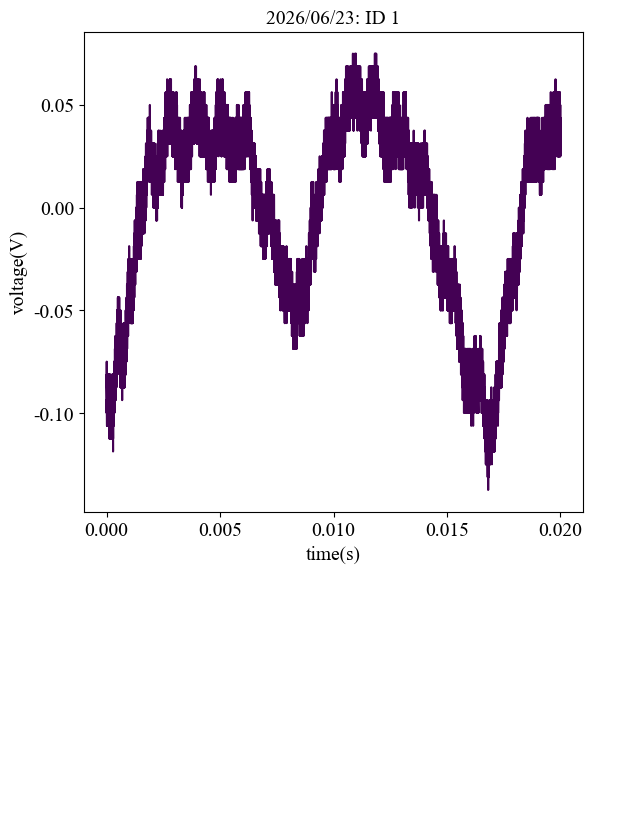

In [13]:
ps.Plot2D(x = t, y = None, Z = v,
          xlabel = "time(s)", zlabel = "voltage(V)")

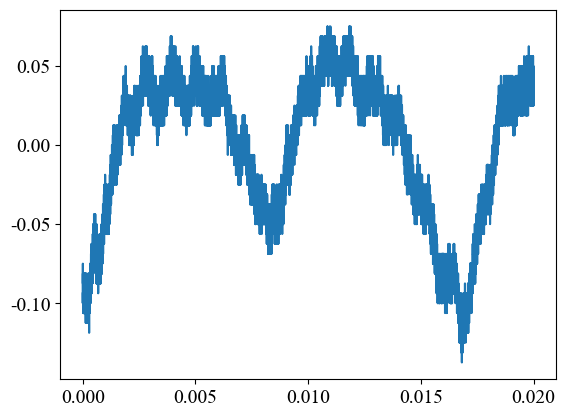

In [5]:
plt.plot(t,v)

In [7]:
rms = np.sqrt(np.mean(v**2))
print(rms)

0.04560522200241001


In [16]:
from DataProcessing import Readout
import numpy as np
import matplotlib.pyplot as plt

In [14]:
root_dir = "Z:/migratedData/Rydberg_QIS/data"
# root_dir = f"/run/user/1000/gvfs/smb-share:server=lsa-graithel-win.turbo.storage.umich.edu,share=lsa-graithel/migratedData/Rydberg_QIS/data"   # Linux
x,y,z,notes = Readout.read_saved_csv_by_id(root_dir=root_dir, date="2026/06/23", plot_id=1)

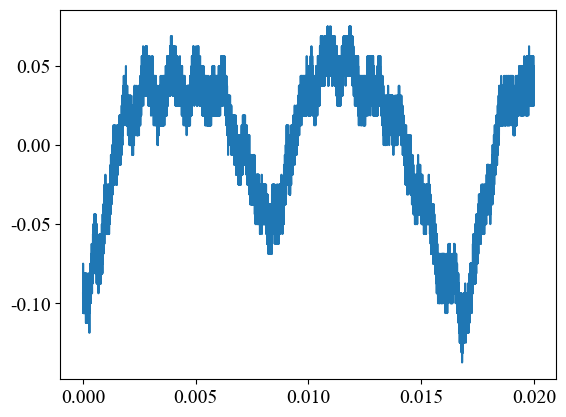

In [18]:
plt.plot(x,z)

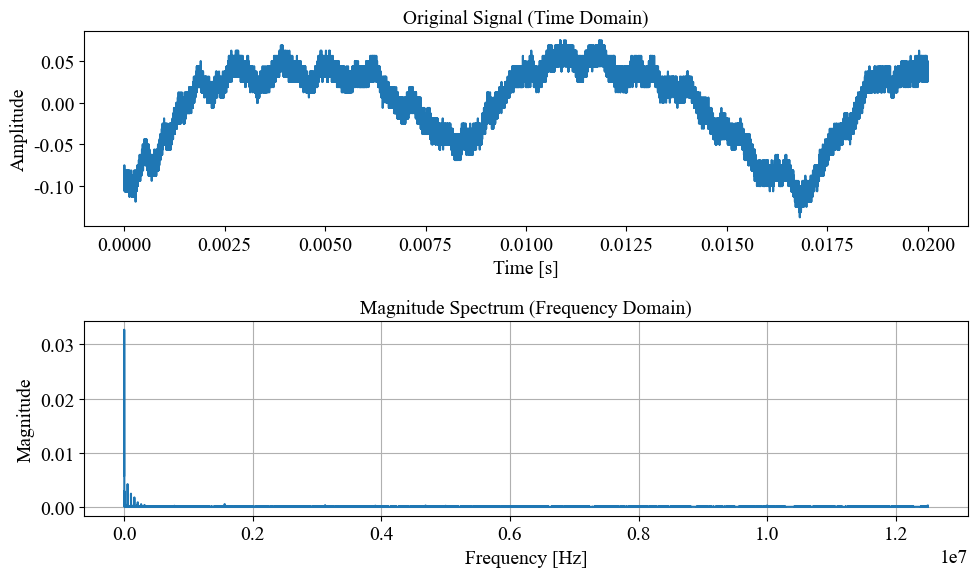

99.99960000159999


In [27]:
fs = 25e6  # Sampling rate


# Compute Fourier Transform
fft_result = np.fft.fft(z)
freqs = np.fft.fftfreq(len(z), 1/fs)
# print(np.shape(freqs))

# Keep only positive frequencies
idz = np.where(freqs >= 0)
freqs = freqs[idz]
magnitude = np.abs(fft_result[idz]) * 2 / len(z)  # Normalize amplitude

# Plot signal and its FFT
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(x, z)
plt.title("Original Signal (Time Domain)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(freqs, magnitude)
plt.title("Magnitude Spectrum (Frequency Domain)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.grid(True)

plt.tight_layout()
plt.show()
print(freqs[np.argmax(magnitude)])

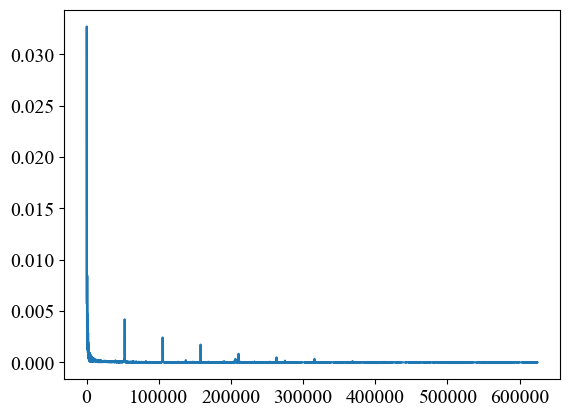

In [39]:
plt.plot(freqs[0:int(len(x)/40)],magnitude[0:int(len(x)/40)])